In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Attention avec les buteurs Garbisi et Smith qui ne sont contés qu'une fois => Il faut aller les différencier dans la base de donnée

In [2]:
data = pd.read_csv("../../data/kick_scorer.csv")

In [3]:
df = data.copy()
df.head(2)

,players,penality,transformation,drops,games_played,points,team
0,Ramos,3,25,0,5,59,France
1,Russell,3,17,0,5,43,Scotland


In [4]:
print(plt.style.available)
plt.style.use('seaborn-v0_8-pastel')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


<h2 style = "text-align : center; color: green">TEAM ANALYSIS</h2>

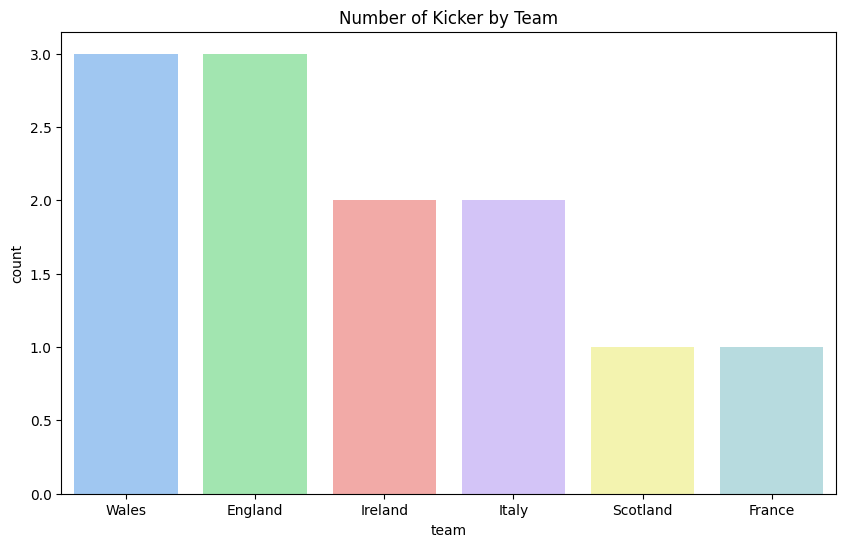

In [5]:
kickers_team = df["team"].value_counts().reset_index()

plt.figure(figsize = (10,6))
sns.barplot(data = kickers_team, x = "team", y = "count", hue = "team")
plt.title("Number of Kicker by Team")
plt.show()

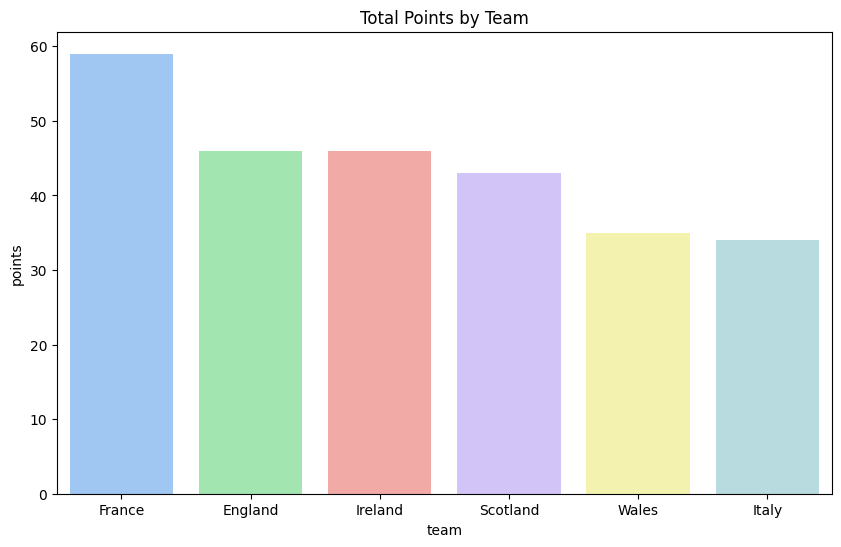

In [6]:
df_kicks = df.groupby(["team"])["points"].sum().reset_index()
df_kicks = df_kicks.sort_values('points', ascending = False)

plt.figure(figsize = (10,6))
sns.barplot(data = df_kicks, x = "team", y = "points", hue = 'team')
plt.title("Total Points by Team")
plt.show()

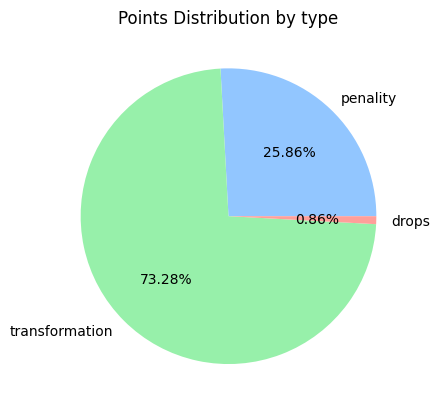

In [7]:
types_points = df[["penality", "transformation", "drops"]].sum()

types_points = types_points[types_points > 0]

types_points.plot.pie(
    autopct='%1.2f%%',
    ylabel="",
    title="Points Distribution by type"
)

plt.show()

In [8]:
df_grouped = df.groupby("team")[["points", "penality", "transformation", "drops"]].sum().reset_index()
df_grouped = df_grouped.sort_values("points", ascending = False)
df_grouped.head(2)

,team,points,penality,transformation,drops
1,France,59,3,25,0
0,England,46,6,14,0


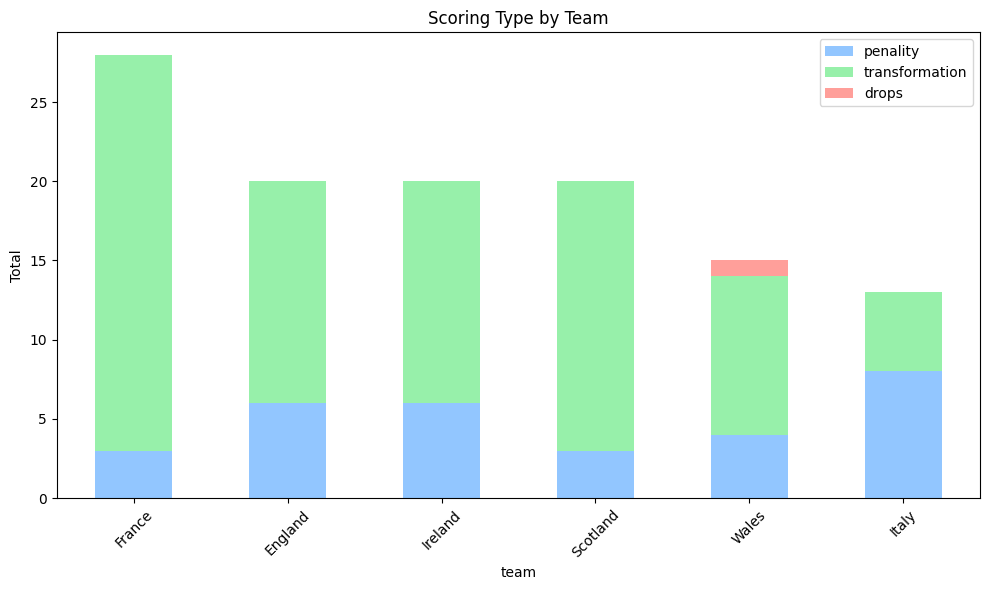

In [9]:
df_grouped.set_index("team")[["penality", "transformation", "drops"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.xticks(rotation=45)
plt.xlabel("team")
plt.ylabel("Total")
plt.title("Scoring Type by Team")
plt.tight_layout()
plt.show()

<h2 style = "text-align : center; color: green">PLAYER ANALYSIS</h2>

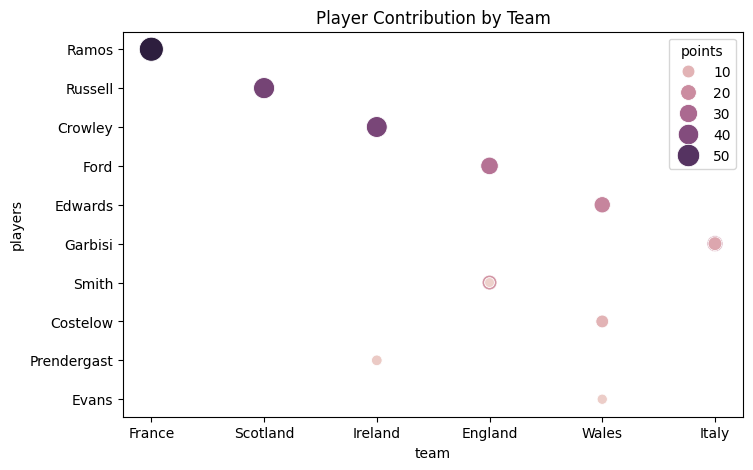

In [10]:
plt.figure(figsize = (8,5))
sns.scatterplot(data = df , x = "team", y = "players", hue = "points", size = "points", sizes=(50, 300), color = "red")
plt.title("Player Contribution by Team")
plt.show()

In [11]:
df_grouped1 = df.groupby("players")[["points", "penality", "transformation", "drops", "games_played"]].sum().reset_index()
df_grouped1 = df_grouped1.sort_values('points', ascending = False)

df_grouped1.head(2)

,players,points,penality,transformation,drops,games_played
7,Ramos,59,3,25,0,5
8,Russell,43,3,17,0,5


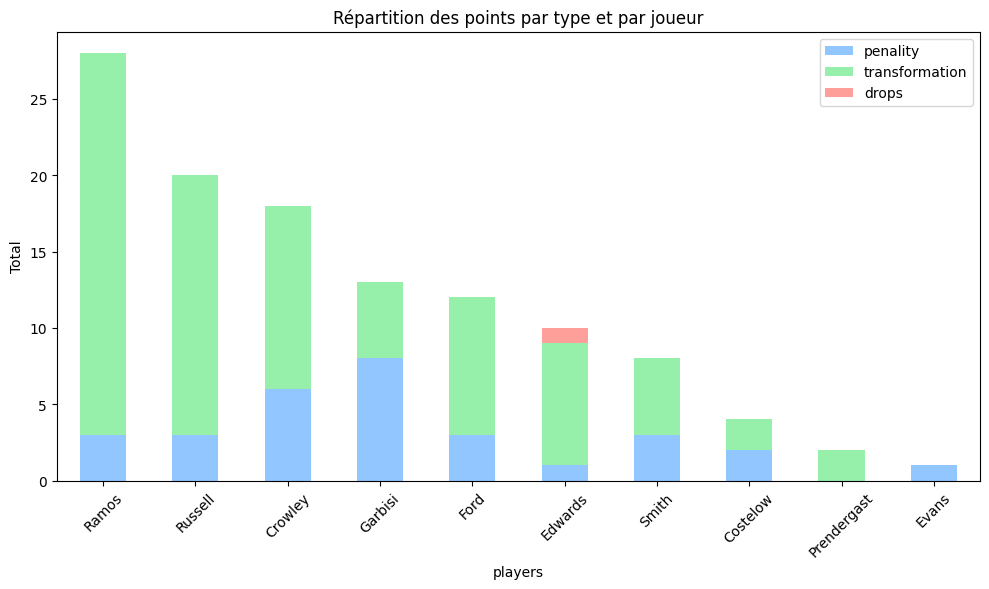

In [12]:
df_grouped1.set_index("players")[["penality", "transformation", "drops"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.xticks(rotation=45)
plt.xlabel("players")
plt.ylabel("Total")
plt.title("Répartition des points par type et par joueur")
plt.tight_layout()
plt.show()